---
## 1. Why CNMFe?

In **2-photon** (2p) microscopy the excitation volume is confined to a tiny focal spot,
so each pixel samples only one or two neurons. Background fluorescence is minimal.

In **1-photon** (1p) endoscopic microscopy (miniscope) the full depth of the sample is
illuminated. Every pixel records:
- the signals of the neurons directly in focus, AND
- a large **diffuse background** from out-of-focus neuropil and scattered light.

This background is:
- spatially smooth (spreads over tens of pixels),
- temporally correlated (slow drift, hemodynamics),
- much larger in amplitude than individual neuron transients.

Standard NMF (CNMF) fails here because it treats each pixel independently: it has no
model for the structured, spatially correlated background, so it fits the background
with spurious neural components.

**CNMFe** (CNMF for Endoscopic data) adds a **ring-model background** — the background
at each pixel is predicted from a weighted sum of pixels in a ring around it. This
model is fit before extracting neural components, so the signal that's left for CNMF
is background-subtracted.

Let's build a synthetic 1p movie to see the problem concretely.

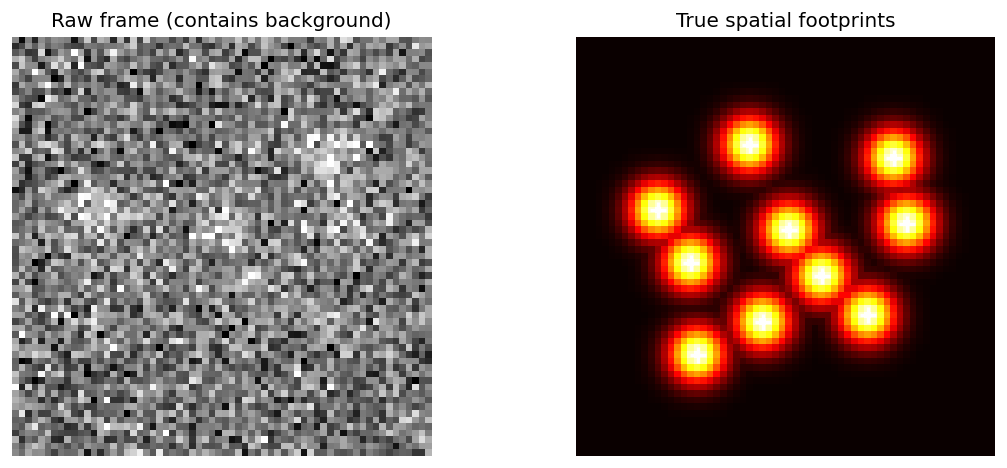

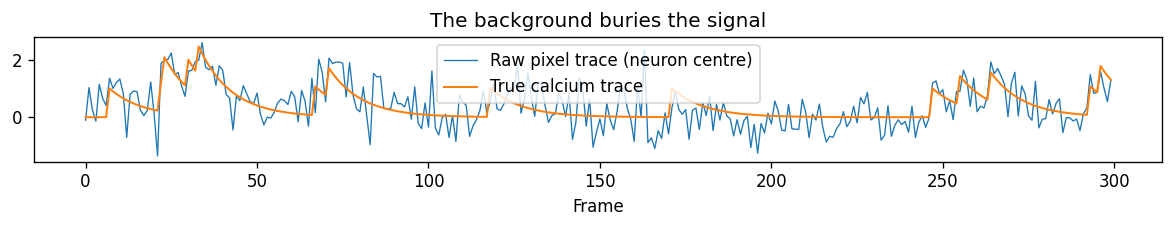

In [24]:
# Visualise: one raw frame vs the true neuron locations
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(movie[100], cmap='gray', vmin=np.percentile(movie, 1), vmax=np.percentile(movie, 99))
axes[0].set_title('Raw frame (contains background)')
axes[0].axis('off')

A_max = A_true.max(axis=1).reshape(H, W)
axes[1].imshow(A_max, cmap='hot')
for r, c in centers:
    axes[1].plot(c, r, 'w+', ms=10, mew=2)
axes[1].set_title('True spatial footprints')
axes[1].axis('off')

plt.tight_layout()
plt.show()

# Show why the background is a problem: a raw pixel trace at a neuron centre
r0, c0 = centers[0]
raw_trace = movie[:, r0, c0]
fig, ax = plt.subplots(figsize=(10, 2))
ax.plot(raw_trace, lw=0.8, label='Raw pixel trace (neuron centre)')
ax.plot(C_true[0], lw=1.2, label='True calcium trace')
ax.set_xlabel('Frame')
ax.legend()
ax.set_title('The background buries the signal')
plt.tight_layout()
plt.show()

In [26]:
import imageio
import os

fps       = 15          # playback speed — lower = easier to see individual transients
scale     = 6           # nearest-neighbour upscale (64→384 px); set to 1 to skip
vmin_pct  = 10          # low percentile for contrast stretch (raise to suppress background)
vmax_pct  = 99.5        # high percentile for contrast stretch

lo, hi = np.percentile(movie, [vmin_pct, vmax_pct])
frames_u8 = ((movie - lo) / (hi - lo + 1e-10) * 255).clip(0, 255).astype(np.uint8)

if scale > 1:
    frames_u8 = frames_u8.repeat(scale, axis=1).repeat(scale, axis=2)

frames_rgb = np.stack([frames_u8] * 3, axis=-1)

out_path = '../synthetic_movie.mp4'
imageio.mimwrite(out_path, frames_rgb, fps=fps)
print(f'Saved → {os.path.abspath(out_path)}  '
      f'({T} frames, {H*scale}×{W*scale} px, {fps} fps)')

Saved → D:\Code\claude_cnmfe\synthetic_movie.mp4  (300 frames, 384×384 px, 15 fps)


In [27]:
import tempfile, os
from minicnmfe.io import save_zarr, open_zarr

tmpdir = tempfile.mkdtemp()
zarr_path = os.path.join(tmpdir, 'movie.zarr')

# Stream movie to zarr (in practice this is avi_to_zarr for video files)
z = save_zarr(movie, zarr_path, chunk_t=100)
print(f'zarr shape : {z.shape}')
print(f'zarr chunks: {z.chunks}')
print(f'zarr dtype : {z.dtype}')

# Random access — only the relevant chunk is read
frame_50 = z[50]
print(f'\nSingle frame access: shape={frame_50.shape}')
print('No full movie loaded — only the chunk containing frame 50 was read.')

zarr shape : (300, 64, 64)
zarr chunks: (100, 64, 64)
zarr dtype : float32

Single frame access: shape=(64, 64)
No full movie loaded — only the chunk containing frame 50 was read.


True drift:           [ 3.7 -2.1]
Detected correction:  [-3.7  2.1]  (expected ≈ [-3.7  2.1])
Error (px):           0.000


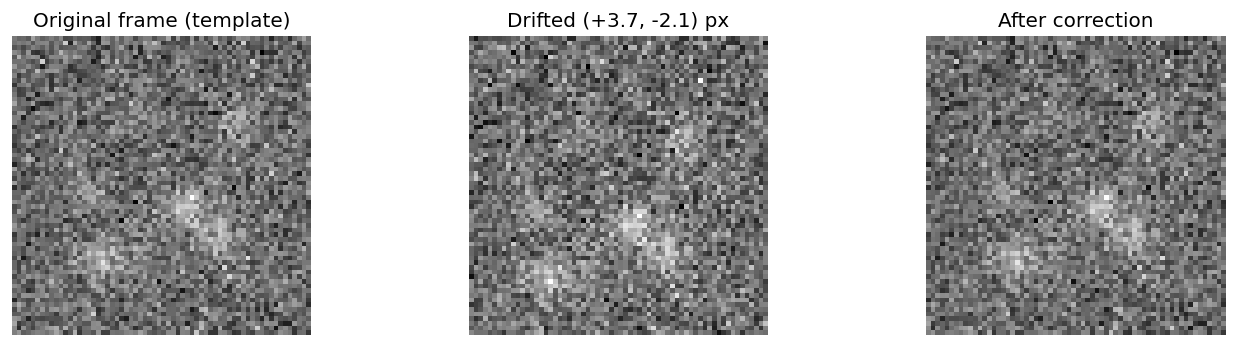

In [28]:
from minicnmfe.motion_correction import estimate_shifts, apply_shift

frame = movie[50].copy()

# Simulate brain drift by applying a known shift
true_drift = np.array([3.7, -2.1], dtype=np.float32)
drifted_frame = apply_shift(frame, true_drift)

# estimate_shifts(drifted, template) returns the CORRECTION shift —
# i.e. what to pass directly to apply_shift to undo the drift.
# Convention matches motion_correct(): apply_shift(frame, estimate_shifts(frame, template)) ≈ template
correction = estimate_shifts(drifted_frame, frame, upsample_factor=20)
print(f'True drift:           {true_drift}')
print(f'Detected correction:  {correction}  (expected ≈ {-true_drift})')
print(f'Error (px):           {np.abs(correction + true_drift).max():.3f}')

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
axes[0].imshow(frame, cmap='gray')
axes[0].set_title('Original frame (template)')
axes[1].imshow(drifted_frame, cmap='gray')
axes[1].set_title(f'Drifted ({true_drift[0]:+.1f}, {true_drift[1]:+.1f}) px')
recovered = apply_shift(drifted_frame, correction)   # correction applied directly — no negation
axes[2].imshow(recovered, cmap='gray')
axes[2].set_title('After correction')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

Motion correction pass 1/1: 100%|██████████| 3/3 [00:00<00:00,  6.29it/s]


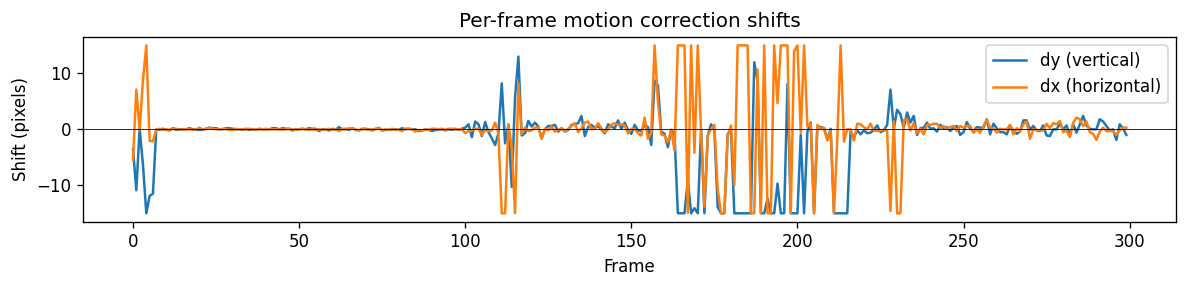

Max |shift|: 15.000 px


In [30]:
from minicnmfe.motion_correction import motion_correct

# Apply motion correction to the full movie
# (our synthetic movie has no motion, so shifts should all be ~0)
mc_movie, shifts = motion_correct(movie, upsample_factor=10, max_shift=(15, 15), n_iter=1)
mc_movie = np.asarray(mc_movie, dtype=np.float32)

fig, ax = plt.subplots(figsize=(10, 2.5))
ax.plot(shifts[:, 0], label='dy (vertical)')
ax.plot(shifts[:, 1], label='dx (horizontal)')
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('Frame')
ax.set_ylabel('Shift (pixels)')
ax.set_title('Per-frame motion correction shifts')
ax.legend()
plt.tight_layout()
plt.show()
print(f'Max |shift|: {np.abs(shifts).max():.3f} px')

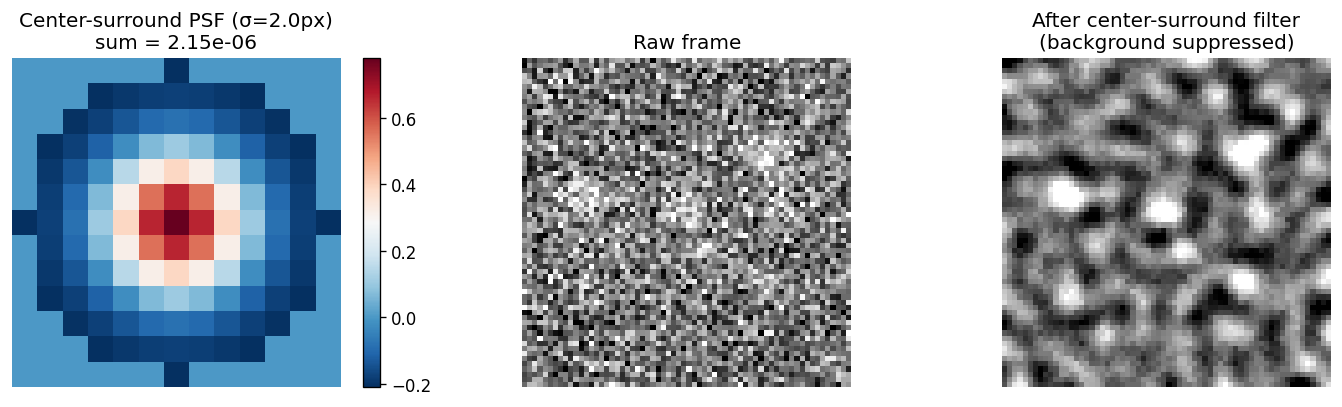

In [31]:
from minicnmfe.preprocess import make_center_surround_psf

sigma = 2.0
psf = make_center_surround_psf(sigma)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

im0 = axes[0].imshow(psf, cmap='RdBu_r')
plt.colorbar(im0, ax=axes[0])
axes[0].set_title(f'Center-surround PSF (σ={sigma}px)\nsum = {psf.sum():.2e}')

# Effect on a single frame
raw_frame = mc_movie[100]
filtered_frame = ndi.convolve(raw_frame, psf, mode='reflect')

vmin, vmax = np.percentile(raw_frame, [2, 98])
axes[1].imshow(raw_frame, cmap='gray', vmin=vmin, vmax=vmax)
axes[1].set_title('Raw frame')

fmin, fmax = np.percentile(filtered_frame, [2, 98])
axes[2].imshow(filtered_frame, cmap='gray', vmin=fmin, vmax=fmax)
axes[2].set_title('After center-surround filter\n(background suppressed)')

for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

---
## 5. Ring-Model Background

Even after the spatial filter, some background survives. The key insight of CNMFe is:

> The background at any given pixel is well approximated by a **weighted sum of pixels
> in a ring around it**, because the background is spatially smooth on scales larger
> than a single neuron.

The ring has inner radius ≈ neuron diameter (so we don't include the neuron itself in
the predictor) and outer radius ≈ inner + 1 pixel.

For each pixel `i`, we solve:
```
min_w  ||Y[i] - A[i]*C[i] - w * Y[ring_i]||²  +  λ||w||²
```
This ridge regression is done **after** subtracting the current neural estimates `A*C`,
so the weights capture only the background.

The result is a sparse weight matrix **W** (shape H×W × H×W) and a per-pixel
baseline **b0**. Background-subtracted data:
```
Y_res = Y - b0 - W @ (Y - b0)
```

W shape: (4096, 4096), nnz: 168292 (41.1 non-zeros per row)


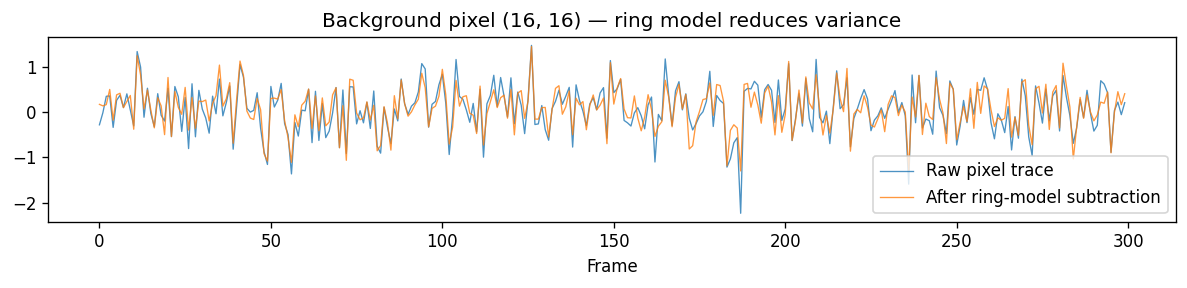

Std before: 0.525
Std after:  0.468


In [34]:
from minicnmfe._utils import make_2d

# To fit W we need a rough initial estimate of A and C
# For demo purposes use the true A and C
A_sp = sp.csc_matrix(A_true.astype(np.float32))
Y_flat = make_2d(mc_movie)   # (H*W, T)

W_mat, b0 = compute_W(Y_flat, A_sp, C_true, (H, W), ring_radius, lambda_reg=1e-5)
print(f'W shape: {W_mat.shape}, nnz: {W_mat.nnz} ({W_mat.nnz / W_mat.shape[0]:.1f} non-zeros per row)')

Y_bg = subtract_background(Y_flat, W_mat, b0)  # (H*W, T)

# Compare background-subtracted vs raw at a background pixel (no neuron there)
bg_row, bg_col = H // 4, W // 4  # pick a pixel away from neurons
px_idx = bg_row * W + bg_col

fig, ax = plt.subplots(figsize=(10, 2.5))
ax.plot(Y_flat[px_idx], lw=0.8, alpha=0.8, label='Raw pixel trace')
ax.plot(Y_bg[px_idx], lw=0.8, alpha=0.8, label='After ring-model subtraction')
ax.set_xlabel('Frame')
ax.set_title(f'Background pixel ({bg_row}, {bg_col}) — ring model reduces variance')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Std before: {Y_flat[px_idx].std():.3f}')
print(f'Std after:  {Y_bg[px_idx].std():.3f}')

Seeds found: 35
Top 5 seeds (row, col) with CORR×PNR score:
  ( 15,  26)  score=9.09
  ( 43,  28)  score=7.74
  ( 29,  51)  score=7.13
  ( 34,  26)  score=6.97
  ( 26,  13)  score=6.87


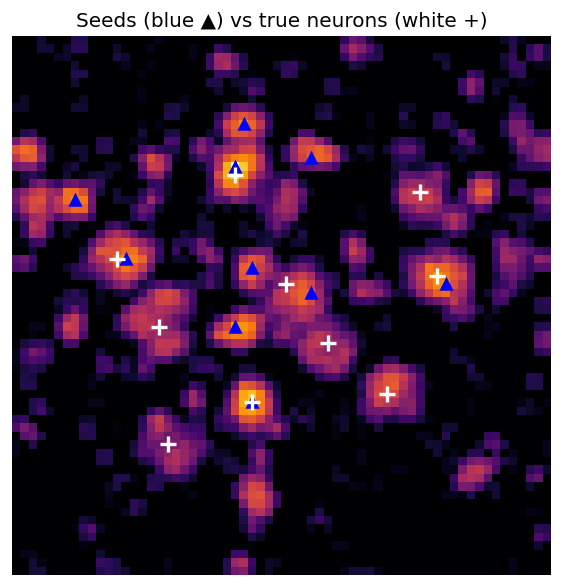

In [35]:
from minicnmfe.initialization import detect_seeds, extract_spatial_temporal, greedy_corr_pnr

# Step-by-step demo of seed detection
seeds = detect_seeds(cn, pnr, min_corr=0.7, min_pnr=4.0, min_distance=int(sigma))
print(f'Seeds found: {len(seeds)}')
print('Top 5 seeds (row, col) with CORR×PNR score:')
for row, col in seeds[:5]:
    print(f'  ({row:3d}, {col:3d})  score={cn[row,col]*pnr[row,col]:.2f}')

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(cn * pnr, cmap='inferno')
for r, c in seeds[:10]:
    ax.plot(c, r, 'b^', ms=6, mew=1.5)
for r, c in centers:
    ax.plot(c, r, 'w+', ms=10, mew=2)
ax.set_title('Seeds (blue ▲) vs true neurons (white +)')
ax.axis('off')
plt.tight_layout()
plt.show()

---
## 7. Spatial and Temporal Refinement

The greedy initialization gives approximate components. We refine them in alternating steps:

### Spatial update
Given fixed temporal traces C, update each spatial footprint by solving a
**per-pixel non-negative LASSO** regression:
```
a_p = argmin  ||Y[p] - C[active].T @ a_p||²  +  λ ||a_p||₁
      a_p ≥ 0
```
Only the components whose current footprint overlaps pixel `p` (within a dilation margin)
are included as regressors. This keeps the problem sparse and fast.

### Temporal update (block coordinate descent)
Given fixed spatial footprints A, update each temporal trace by:
1. Project data onto component: `trace_k = (Y.T @ a_k - crosstalk) / ||a_k||²`
2. Deconvolve with **OASIS** (Online Active Set Identification for Spiking data) to get
   a non-negative spike train `s_k` and a smooth calcium trace `c_k` that obeys the
   AR(1) model: `c_k[t] = g * c_k[t-1] + s_k[t]`.

The AR(1) parameter `g` (calcium decay constant) is estimated per-component from
the high-frequency autocorrelation of the raw trace.

### Component merging
Two components that are both spatially overlapping AND temporally correlated are likely
the same neuron detected twice. We merge them by summing their footprints and averaging
their traces, then re-deconvolving.

Clean init: 30 components
Component 1 matches true neuron 0  (spatial corr = 0.96)
Temporal correlation with ground truth:  before=0.919  after=0.671


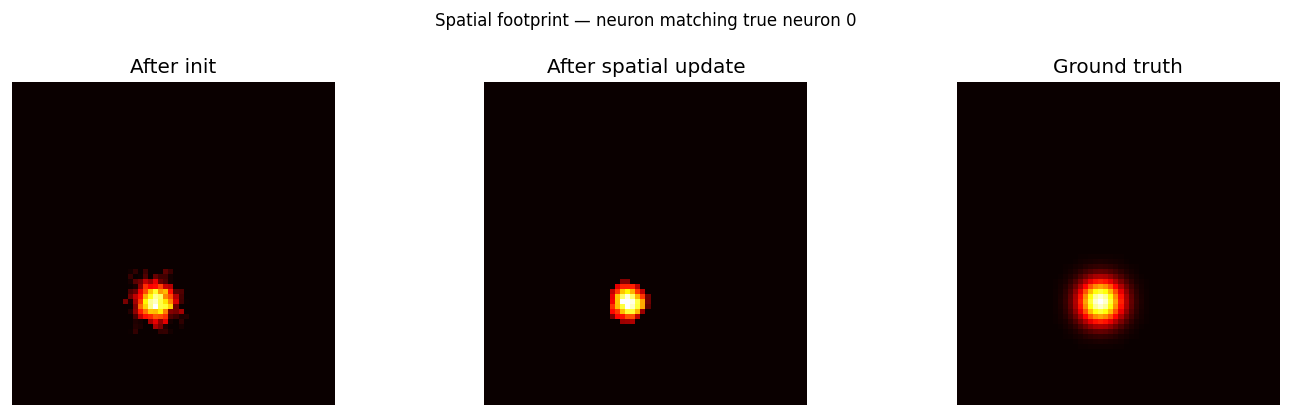

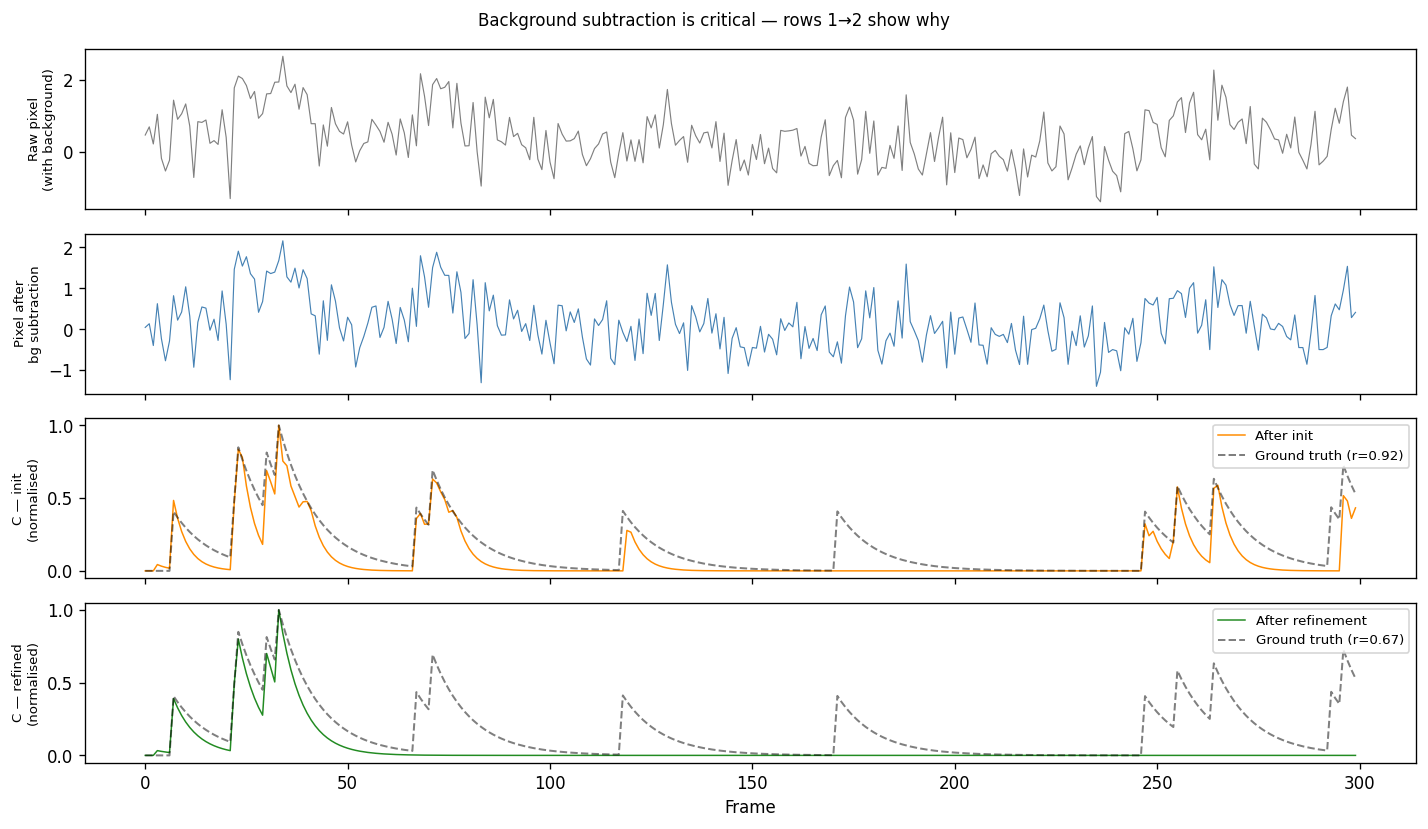

In [38]:
from minicnmfe.spatial import update_spatial
from minicnmfe.temporal import update_temporal
from minicnmfe.background import compute_W, subtract_background
from minicnmfe.initialization import greedy_corr_pnr as gcp
from tests.test_pipeline import match_components

# Run a clean init with tighter thresholds for the refinement demo
# (avoids the ~100 spurious components that the loose cell-20 init produces)
A_demo, C_demo, _, centers_demo = gcp(
    mc_movie, sigma=sigma, min_corr=0.7, min_pnr=3.0, ar_order=1, border_px=5
)
K_demo = A_demo.shape[1]
print(f'Clean init: {K_demo} components')

if K_demo > 0:
    sn_flat = np.ones(H * W, dtype=np.float32) * data['sn_true']
    ring_radius = 1.5 * (2 * sigma + 1)
    W_demo, b0_demo = compute_W(Y_flat, A_demo, C_demo, (H, W), ring_radius)
    Y_bg_demo = subtract_background(Y_flat, W_demo, b0_demo)
    A_refined = update_spatial(Y_bg_demo, C_demo, A_demo, sn_flat, (H, W), dilation_radius=3)
    C_refined, S_refined, _, _ = update_temporal(Y_bg_demo, A_refined, C_demo, sn_flat,
                                                 ar_order=1, n_iter=2)

    matches = match_components(A_demo, data['A_true'])
    k_true_demo, k_est_demo, spatial_corr = matches[0]  # true neuron 0
    print(f'Component {k_est_demo} matches true neuron {k_true_demo}  '
          f'(spatial corr = {spatial_corr:.2f})')

    def pearson(a, b):
        a = a - a.mean(); b = b - b.mean()
        denom = np.sqrt(np.sum(a**2) * np.sum(b**2))
        return float(np.dot(a, b) / denom) if denom > 0 else 0.0

    r_before = pearson(C_demo[k_est_demo], data['C_true'][k_true_demo])
    r_after  = pearson(C_refined[k_est_demo], data['C_true'][k_true_demo])
    print(f'Temporal correlation with ground truth:  before={r_before:.3f}  after={r_after:.3f}')

    # --- Spatial footprints: before / after / ground truth ---
    a_before = np.asarray(A_demo[:, k_est_demo].todense()).ravel().reshape(H, W)
    a_after  = np.asarray(A_refined[:, k_est_demo].todense()).ravel().reshape(H, W)
    a_true   = data['A_true'][:, k_true_demo].reshape(H, W)

    fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
    for ax, img, title in zip(axes,
                               [a_before, a_after, a_true],
                               ['After init', 'After spatial update', 'Ground truth']):
        ax.imshow(img, cmap='hot')
        ax.set_title(title)
        ax.axis('off')
    plt.suptitle('Spatial footprint — neuron matching true neuron 0', fontsize=10)
    plt.tight_layout(); plt.show()

    # --- Temporal traces: normalize to [0,1] so amplitude units don't confuse the comparison ---
    # C_demo traces are in normalized-correlation units (output of extract_spatial_temporal),
    # while C_true is in fluorescence units.  Plotting both on [0,1] reveals *shape* similarity.
    def norm01(x):
        lo, hi = x.min(), x.max()
        return (x - lo) / (hi - lo + 1e-10)

    r0_n, c0_n = centers_demo[k_est_demo]
    px_idx = int(r0_n) * W + int(c0_n)

    fig, axes = plt.subplots(4, 1, figsize=(12, 7), sharex=True)
    axes[0].plot(Y_flat[px_idx], lw=0.7, color='gray')
    axes[0].set_ylabel('Raw pixel\n(with background)', fontsize=8)

    axes[1].plot(Y_bg_demo[px_idx], lw=0.7, color='steelblue')
    axes[1].set_ylabel('Pixel after\nbg subtraction', fontsize=8)

    axes[2].plot(norm01(C_demo[k_est_demo]), lw=0.9, color='darkorange', label='After init')
    axes[2].plot(norm01(data['C_true'][k_true_demo]), lw=1.2, linestyle='--', color='k',
                 alpha=0.5, label=f'Ground truth (r={r_before:.2f})')
    axes[2].legend(fontsize=8, loc='upper right')
    axes[2].set_ylabel('C — init\n(normalised)', fontsize=8)

    axes[3].plot(norm01(C_refined[k_est_demo]), lw=0.9, color='forestgreen', label='After refinement')
    axes[3].plot(norm01(data['C_true'][k_true_demo]), lw=1.2, linestyle='--', color='k',
                 alpha=0.5, label=f'Ground truth (r={r_after:.2f})')
    axes[3].legend(fontsize=8, loc='upper right')
    axes[3].set_ylabel('C — refined\n(normalised)', fontsize=8)
    axes[3].set_xlabel('Frame')

    plt.suptitle('Background subtraction is critical — rows 1→2 show why', fontsize=10)
    plt.tight_layout(); plt.show()
else:
    print('No components found — try lowering min_corr/min_pnr')

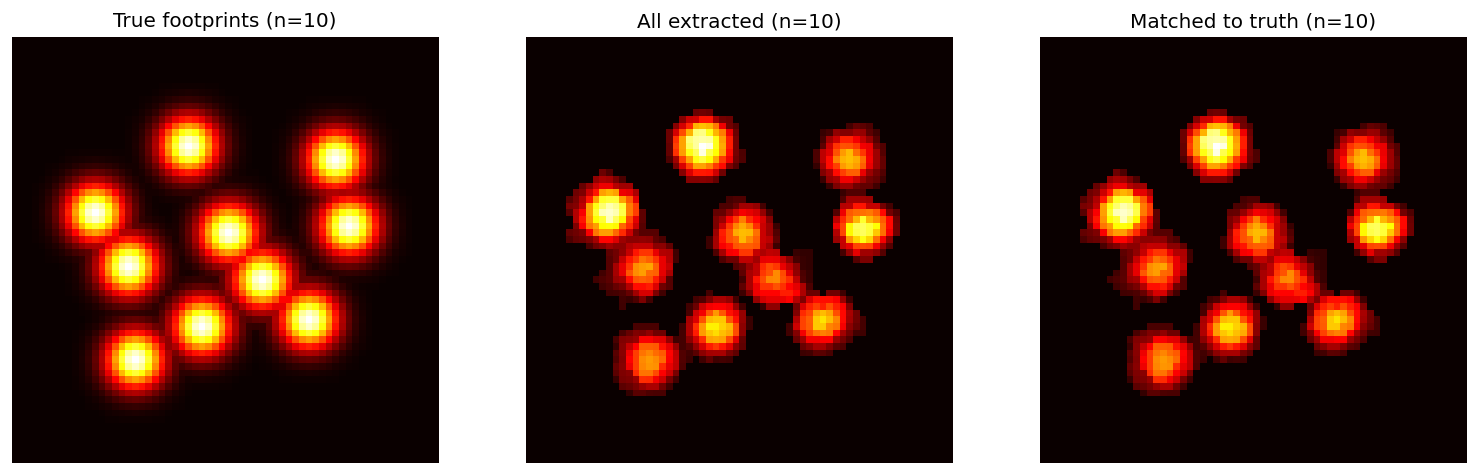

Recovered 10/10 true neurons (r > 0.5)

Spatial correlation per true neuron:
  true 0 <-> extracted 1: r = 0.965
  true 1 <-> extracted 3: r = 0.973
  true 2 <-> extracted 6: r = 0.969
  true 3 <-> extracted 0: r = 0.979
  true 4 <-> extracted 7: r = 0.973
  true 5 <-> extracted 4: r = 0.982
  true 6 <-> extracted 5: r = 0.964
  true 7 <-> extracted 9: r = 0.977
  true 8 <-> extracted 8: r = 0.947
  true 9 <-> extracted 2: r = 0.957


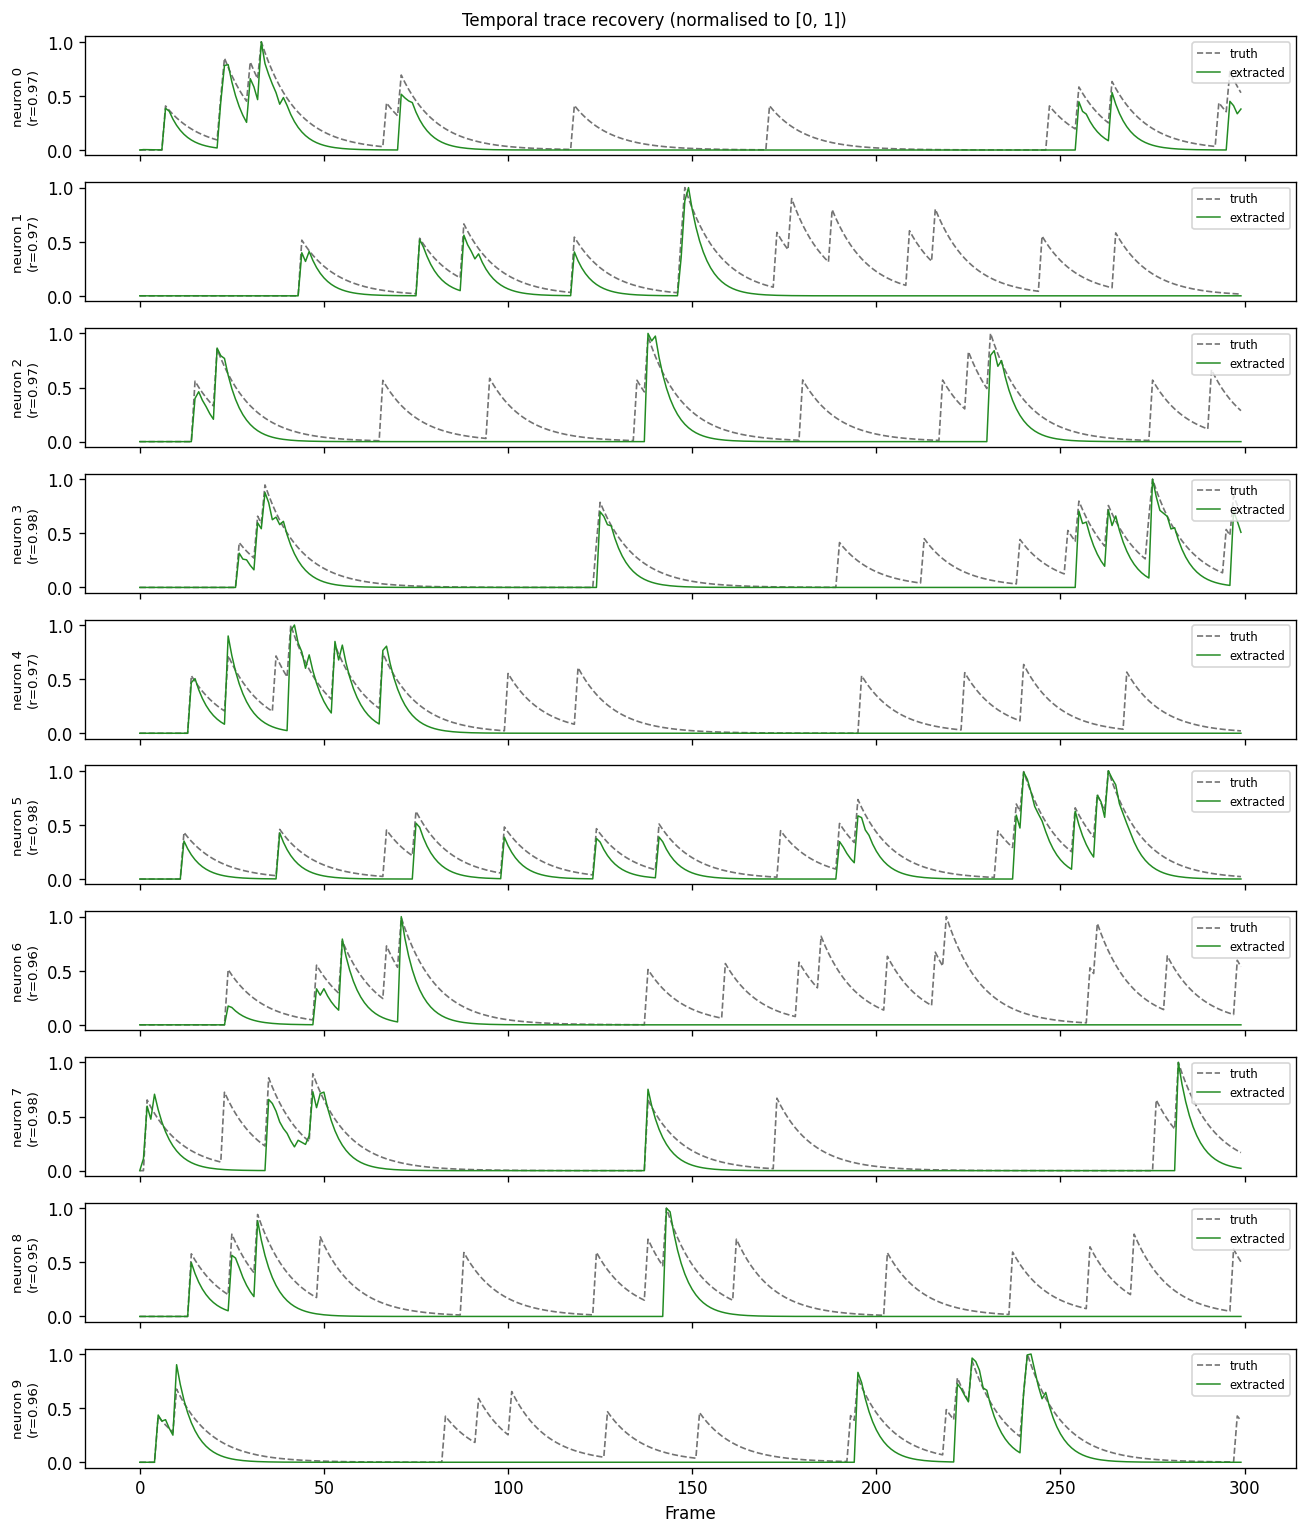

In [41]:
from tests.test_pipeline import match_components

K_found = model.A.shape[1]

if K_found > 0:
    A_dense = np.asarray(model.A.todense()).reshape(H, W, K_found)
    matches = match_components(model.A, A_true)
    matched_idxs = sorted({k_est for _, k_est, c in matches if c > 0.5})
    unmatched = [k for k in range(K_found) if k not in matched_idxs]

    # --- Spatial overlays: truth | all extracted | matched-only ---
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))

    axes[0].imshow(A_true.max(axis=1).reshape(H, W), cmap='hot')
    axes[0].set_title(f'True footprints (n={K})')
    axes[0].axis('off')

    axes[1].imshow(A_dense.max(axis=2), cmap='hot')
    axes[1].set_title(f'All extracted (n={K_found})')
    axes[1].axis('off')

    matched_overlay = (
        A_dense[:, :, matched_idxs].max(axis=2) if matched_idxs else np.zeros((H, W))
    )
    axes[2].imshow(matched_overlay, cmap='hot')
    axes[2].set_title(f'Matched to truth (n={len(matched_idxs)})')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

    print(f'Recovered {len(matched_idxs)}/{K} true neurons (r > 0.5)')
    if unmatched:
        print(f'Unmatched extracted components: {len(unmatched)}  '
              f'(typically background patches passing loose min_corr/min_pnr)')
    print()
    print('Spatial correlation per true neuron:')
    for k_true, k_est, corr in sorted(matches):
        print(f'  true {k_true} <-> extracted {k_est}: r = {corr:.3f}')

    # --- Temporal trace recovery for each matched true neuron ---
    def norm01(x):
        lo, hi = x.min(), x.max()
        return (x - lo) / (hi - lo + 1e-10)

    if matches:
        n_rows = len(matches)
        fig, axes = plt.subplots(n_rows, 1, figsize=(11, 1.3 * n_rows), sharex=True)
        if n_rows == 1:
            axes = [axes]
        for ax, (k_true, k_est, corr) in zip(axes, sorted(matches)):
            ax.plot(norm01(C_true[k_true]), lw=1.0, color='black',
                    linestyle='--', alpha=0.55, label='truth')
            ax.plot(norm01(model.C[k_est]), lw=0.9, color='forestgreen',
                    label='extracted')
            ax.set_ylabel(f'neuron {k_true}\n(r={corr:.2f})', fontsize=8)
            ax.legend(loc='upper right', fontsize=7)
        axes[-1].set_xlabel('Frame')
        plt.suptitle('Temporal trace recovery (normalised to [0, 1])', fontsize=10)
        plt.tight_layout()
        plt.show()
else:
    print('No neurons found - try lowering min_corr or min_pnr')

---
## 9. Parallelism — CPU Multi-core and GPU Acceleration

Two orthogonal knobs control compute performance:

### `n_jobs` — CPU parallelism (joblib/loky)

Independent operations (PSF convolution per frame, LASSO per pixel, OASIS per component)
are dispatched to a pool of worker processes via **joblib**.

```python
n_jobs=1    # serial — default, lowest overhead, best for small movies
n_jobs=4    # 4 worker processes
n_jobs=-1   # all available CPU cores
```

> **Windows note**: workers are spawned with `spawn` (no `fork`). Always call
> `CNMFe(...).fit(...)` inside an `if __name__ == "__main__":` guard in scripts.

### `device` — GPU acceleration (CuPy)

When `device="cuda"` the following steps run on the GPU:

| Step | GPU operation |
|------|--------------|
| Motion correction | FFT2 + phase multiply per frame (`apply_shift`) |
| CORR/PNR images | Per-frame PSF convolution + FFT correlation |
| Ring background | Batched `linalg.solve` grouped by ring size |
| Temporal projection | `(H·W × T) @ (H·W × K)` matrix multiply |
| Greedy init | Initial per-frame PSF convolution |

Steps that stay on CPU regardless of `device`:
- Shift *estimation* (requires `skimage`, no GPU equivalent)
- OASIS deconvolution (sequential PAVA algorithm)
- Spatial LassoLars (sklearn, CPU-only)
- The greedy extraction loop (inherently sequential)

**GPU benefit scales with movie size**: for small movies (< 64×64, T < 500) the
CPU↔GPU transfer overhead dominates and GPU may be *slower*. For large recordings
(≥ 256×256, T ≥ 1000) expect 3–10× end-to-end speedup.

**Install CuPy** matching your CUDA version:
```bash
pip install cupy-cuda12x   # CUDA 12.x
pip install cupy-cuda11x   # CUDA 11.x
```